# **Modeling and Evaluation: Predict SalePrice

## Objectives

* Build, train, and evaluate machine learning models to predict house sale prices.
* Create and validate a reusable feature engineering pipeline for modeling.
* Compare model performance between a full feature set and a reduced model using only the most important features.
* Perform hyperparameter optimization on selected models (Lasso, RandomForest, XGBoost).
* Assess model performance using RMSE, MAE, and R² on both log-transformed and original target scales.
* Identify the most appropriate model for deployment based on performance and simplicity trade-offs.

## Inputs

* Cleaned training and test sets (including log-transformed target variable `SalePrice`).
* List of most important features selected from previous analysis.
* Preprocessed data from earlier pipeline steps.


## Outputs

* Final trained and evaluated models for both full and reduced feature sets.
* A reusable and modular feature engineering pipeline built using `sklearn` and `feature_engine`.
* Performance metrics on train/test sets in both original and log-transformed scales.
* Reusable evaluation function for consistent model comparison.
* Narrative comparison between simplified and full-feature models.
* Exported final model and pipeline as `.pkl` files for use in deployment.


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5\\heritage-housing-ml-pgz\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5\\heritage-housing-ml-pgz'

# Step 1: Load Data

Section 1 content

In [4]:
import numpy as np
import pandas as pd
df = (pd.read_csv("outputs/datasets/collection/house_prices_records.csv"))

print(df.shape)
df.head(3)

(1460, 24)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500


---

## ML pipeline for Data Cleaning and Feature Engineering

Section 2 content

In [5]:
from sklearn.pipeline import Pipeline
from feature_engine.encoding import OrdinalEncoder
from feature_engine.imputation import (
    MeanMedianImputer,
    CategoricalImputer,
    ArbitraryNumberImputer
)
from feature_engine.transformation import LogTransformer
from feature_engine.selection import DropFeatures, SmartCorrelatedSelection

def PipelineDataCleaningAndFeatureEngineering():
    pipeline_base = Pipeline([

        # 1. Drop irrelevant features (including GarageYrBlt)
        ("DropInitialFeatures", DropFeatures(
            features_to_drop=["WoodDeckSF", "EnclosedPorch"]
        )),

        # 2. Ordinal Encoding with suffix "_Enc"
        ("OrdinalEncoder", OrdinalEncoder(
            encoding_method="arbitrary",
            variables=["KitchenQual", "GarageFinish", "BsmtExposure", "BsmtFinType1"],
            missing_values='ignore'
        )),

        # 3a. Median Imputation
        ("ImputeMedian", MeanMedianImputer(
            imputation_method="median",
            variables=["2ndFlrSF", "LotFrontage"]
        )),

        # 3b. Mode Imputation
        ("ImputeMode", CategoricalImputer(
            imputation_method="frequent",
            variables=["BedroomAbvGr", "GarageFinish", "BsmtExposure", "BsmtFinType1"],
            ignore_format=True
        )),

        # 3c. Impute 0 for MasVnrArea
        ("ImputeZero", ArbitraryNumberImputer(
            arbitrary_number=0,
            variables=["MasVnrArea"]
        )),

        # 4. Log10 Transformation
        ("LogTransformer", LogTransformer(
            variables=["LotArea", "LotFrontage"],
            base="10"
        )),

        # 5. Drop highly correlated features
        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            method="spearman",
            threshold=0.7,
            selection_method="variance"
        )),
    ])
    
    return pipeline_base

PipelineDataCleaningAndFeatureEngineering()


Pipeline(steps=[('DropInitialFeatures',
                 DropFeatures(features_to_drop=['WoodDeckSF',
                                                'EnclosedPorch'])),
                ('OrdinalEncoder',
                 OrdinalEncoder(encoding_method='arbitrary',
                                missing_values='ignore',
                                variables=['KitchenQual', 'GarageFinish',
                                           'BsmtExposure', 'BsmtFinType1'])),
                ('ImputeMedian',
                 MeanMedianImputer(variables=['2ndFlrSF', 'LotFrontage'])),
                ('ImputeMode',
                 Cat...
                                    variables=['BedroomAbvGr', 'GarageFinish',
                                               'BsmtExposure',
                                               'BsmtFinType1'])),
                ('ImputeZero',
                 ArbitraryNumberImputer(arbitrary_number=0,
                                        variables=['MasVnrArea'])),
                ('LogTransformer',
                 LogTransformer(base='10',
                                variables=['LotArea', 'LotFrontage'])),
                ('SmartCorrelatedSelection',
                 SmartCorrelatedSelection(method='spearman',
                                          selection_method='variance',
                                          threshold=0.7))])

## ML Pipeline for Modelling and Hyperparameter Optimisation

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

def PipelineReg(model):
    pipeline = Pipeline([
        ("scaler", StandardScaler()), 
        ("feature_selection", SelectFromModel(model, threshold="mean")),  
        ("model", model)  
    ])
    return pipeline

In [7]:
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd

class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs=-1, verbose=1, scoring='neg_root_mean_squared_error', refit=True):
        for key in self.keys:
            print(f"\n Running GridSearchCV for {key} \n")
            model = PipelineReg(self.models[key])
            gs = GridSearchCV(
                model,
                self.params[key],
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose,
                scoring=scoring,
                refit=refit
            )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            return pd.Series({**params, **{
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                split_scores = self.grid_searches[k].cv_results_[f'split{i}_test_score']
                scores.append(np.array(split_scores).reshape(len(params), 1))
            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append(row(k, s, p))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        score_cols = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        return df[score_cols + [c for c in df.columns if c not in score_cols]], self.grid_searches


### Model + Parameter Grids

In [8]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "Lasso": Lasso(random_state=42)
}

params = {
    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6, 10],
        "model__learning_rate": [0.01, 0.1]
    },
    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1, 1]
    }
}


## Split Train and Test Set

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['SalePrice'], axis=1),
    df['SalePrice'],
    test_size=0.2,
    random_state=0,
)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1168, 23) (1168,) (292, 23) (292,)


## Modeling  the Target Variable SalePrice and Evaluating Results


We now have all the necessary preprocessing steps in place to begin modeling the target variable, SalePrice. To start, we will load our custom data cleaning and feature engineering pipeline.

The first model we will test is Linear Regression, which provides a useful performance baseline. After that, we will proceed with hyperparameter optimization to identify the best-performing model for our use case.

The steps are as follows:

- Load and execute the ML pipeline
- Apply a natural logarithm transformation to SalePrice
- Fit and evaluate a Linear Regression model
- Perform hyperparameter optimization to improve model performance

### Executing the ML Pipeline

In [10]:
pipeline_data_cleaning_feat_eng = PipelineDataCleaningAndFeatureEngineering()
X_train = pipeline_data_cleaning_feat_eng.fit_transform(X_train)
X_test = pipeline_data_cleaning_feat_eng.transform(X_test)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1168, 18) (1168,) (292, 18) (292,)


c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\PabloGalin

### Log Transformation of `SalePrice`

In [11]:
import numpy as np

y_train_log = np.log10(y_train)
y_test_log = np.log10(y_test)

### Execute Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train_log)

y_pred_train_log = linreg.predict(X_train)
y_pred_test_log = linreg.predict(X_test)


### Evaluate Linear Regression

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_log_model(y_true_log, y_pred_log, dataset_name=""):
    print(f"--- {dataset_name} (log10 scale) ---")
    print("R2 Score:", r2_score(y_true_log, y_pred_log))
    print("MAE:", mean_absolute_error(y_true_log, y_pred_log))
    print("RMSE:", np.sqrt(mean_squared_error(y_true_log, y_pred_log)))

evaluate_log_model(y_train_log, y_pred_train_log, "Train Set")
evaluate_log_model(y_test_log, y_pred_test_log, "Test Set")


--- Train Set (log10 scale) ---
R2 Score: 0.8815642527027605
MAE: 0.039609938728532225
RMSE: 0.06005685164559932
--- Test Set (log10 scale) ---
R2 Score: 0.6868033590934346
MAE: 0.04452795184963302
RMSE: 0.09457047488867414


#### Log-transformation of SalePrice

In [14]:
y_pred_train = np.power(10, y_pred_train_log)
y_pred_test = np.power(10, y_pred_test_log)


In [15]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_original_scale(y_true, y_pred, dataset_name=""):
    print(f"--- {dataset_name} (original scale) ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

# Evaluate
evaluate_original_scale(y_train, y_pred_train, "Train Set")
evaluate_original_scale(y_test, y_pred_test, "Test Set")


--- Train Set (original scale) ---
R2 Score: 0.7842603937563851
MAE: 16495.37964689997
RMSE: 36445.85252880444
--- Test Set (original scale) ---
R2 Score: -3.6643135799021467
MAE: 27023.640379668206
RMSE: 179474.37078276268


### Linear Regression Results – Using `log10(SalePrice)`

To establish a baseline model, we applied a **Linear Regression** algorithm using our custom preprocessing pipeline. The target variable `SalePrice` was transformed using a base-10 logarithm (`log10`) to reduce skewness and stabilize variance.



#### Evaluation on Logarithmic Scale (`log10(SalePrice)`)

| Dataset   | R² Score | MAE   | RMSE  |
|-----------|----------|-------|-------|
| Train Set | 0.88     | 0.039 | 0.060 |
| Test Set  | 0.69     | 0.044 | 0.094 |

- The model performs well on the training set and shows decent generalization on the test set.
- Although the R² score on the test set is slightly below the target of 0.75, the results indicate that the model captures key relationships in the data.



#### Evaluation on Original Scale (After Back-Transformation)

To interpret model performance in actual currency values, we applied the inverse transformation (`10^x`) to the predicted target values.

| Dataset   | R² Score | MAE (€) | RMSE (€) |
|-----------|----------|---------|----------|
| Train Set | 0.79     | 16,151  | 35,872   |
| Test Set  | -3.54    | 26,652  | 177,000  |

- While the training set retains good performance, the test set exhibits a negative R², indicating that predictions are worse than simply predicting the average.
- Therefore, we focus our evaluation on the log-transformed target, which reflects model performance more accurately.


#### Hyperparameter Optimization

Now that we have a baseline model, we will explore additional regression algorithms to identify a model that better predicts our target variable, `SalePrice`.

To do this, we will use our custom hyperparameter optimization class along with dedicated pipelines for each model. The goal is to evaluate and compare the performance of the following three regression models:

- Random Forest Regressor  
- XGBoost Regressor  
- Lasso Regression 



In [16]:
search = HyperparameterOptimizationSearch(models, params)
search.fit(X_train, y_train_log, cv=5, verbose=2)

summary_df, gs_dict = search.score_summary()
summary_df.head()


 Running GridSearchCV for RandomForest 

Fitting 5 folds for each of 6 candidates, totalling 30 fits



 Running GridSearchCV for XGBoost 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):



 Running GridSearchCV for Lasso 

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__n_estimators,model__learning_rate,model__alpha
18,Lasso,-0.084477,-0.060618,-0.047391,0.013951,NaN,NaN,NaN,0.001
19,Lasso,-0.082465,-0.064043,-0.051985,0.011505,NaN,NaN,NaN,0.01
12,XGBoost,-0.078971,-0.071226,-0.059103,0.006848,3,100,0.1,NaN
14,XGBoost,-0.077382,-0.072208,-0.060023,0.006266,6,100,0.1,NaN
13,XGBoost,-0.080142,-0.072804,-0.060974,0.006884,3,200,0.1,NaN


#### Evaluation of Hyperparameter Optimization Results

To evaluate model performance, we use three standard regression metrics:

- **Mean Absolute Error (MAE)**: Measures the average absolute difference between actual and predicted values.
- **Root Mean Squared Error (RMSE)**: Measures the square root of the average squared differences, giving more weight to larger errors.
- **R² Score (Coefficient of Determination)**: Indicates how well the model explains the variance in the target variable.

Since the target variable `SalePrice` was log-transformed during training, we evaluate model performance on both the **log scale** and the **original scale** (after inverse transformation). This allows us to assess both model fit and interpretability in actual currency values.


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def Evaluate_Function_Hyper(gs_dict, X_train, X_test, y_train, y_test, y_train_log, y_test_log):
    models = {
        name: gs.best_estimator_
        for name, gs in gs_dict.items()
    }

    print("evaluate_original_scale")
    print("-" * 40)
    for name, model in models.items():
        print(f"{name.upper()}")
        y_train_pred = 10 ** model.predict(X_train)
        y_test_pred = 10 ** model.predict(X_test)

        print("  Train RMSE:", mean_squared_error(y_train, y_train_pred, squared=False))
        print("  Test RMSE: ", mean_squared_error(y_test, y_test_pred, squared=False))
        print("  Train MAE: ", mean_absolute_error(y_train, y_train_pred))
        print("  Test MAE:  ", mean_absolute_error(y_test, y_test_pred))
        print("  Train R²:  ", r2_score(y_train, y_train_pred))
        print("  Test R²:   ", r2_score(y_test, y_test_pred))
        print("-" * 40)

    print("evaluate_log_model")
    print("-" * 40)
    for name, model in models.items():
        print(f"{name.upper()}")
        y_train_pred_log = model.predict(X_train)
        y_test_pred_log = model.predict(X_test)

        print("  Train RMSE:", mean_squared_error(y_train_log, y_train_pred_log, squared=False))
        print("  Test RMSE: ", mean_squared_error(y_test_log, y_test_pred_log, squared=False))
        print("  Train MAE: ", mean_absolute_error(y_train_log, y_train_pred_log))
        print("  Test MAE:  ", mean_absolute_error(y_test_log, y_test_pred_log))
        print("  Train R²:  ", r2_score(y_train_log, y_train_pred_log))
        print("  Test R²:   ", r2_score(y_test_log, y_test_pred_log))
        print("-" * 40)


In [18]:
Evaluate_Function_Hyper(
    gs_dict=gs_dict,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    y_train_log=y_train_log,
    y_test_log=y_test_log
)


evaluate_original_scale
----------------------------------------
RANDOMFOREST
  Train RMSE: 15815.014439160403
  Test RMSE:  34746.94831436223
  Train MAE:  11183.78356853396
  Test MAE:   21563.705191266625
  Train R²:   0.9593769207391274
  Test R²:    0.8251699032770448
----------------------------------------
XGBOOST
  Train RMSE: 23580.090173783337
  Test RMSE:  29892.73189081443
  Train MAE:  16979.2932664009
  Test MAE:   19776.149601348458
  Train R²:   0.9096923423810974
  Test R²:    0.8706060188747459
----------------------------------------
LASSO
  Train RMSE: 35864.409089641136
  Test RMSE:  170015.77837976758
  Train MAE:  16475.435879432116
  Test MAE:   26236.684714441653
  Train R²:   0.7910891413721715
  Test R²:    -3.185634650151129
----------------------------------------
evaluate_log_model
----------------------------------------
RANDOMFOREST
  Train RMSE: 0.03718433749693377
  Test RMSE:  0.07055419947581333
  Train MAE:  0.02801309201658922
  Test MAE:   0.05056

#### Model Evaluation Summary

We evaluated three regression models using log-transformed target values (`log10(SalePrice)`), and then back-transformed predictions to assess performance in the original scale. The models tested were:

- Lasso Regression
- Random Forest Regressor
- XGBoost Regressor


##### Performance on Log Scale

| Model        | Test R² | Test RMSE | Test MAE |
|--------------|---------|-----------|----------|
| Lasso        | 0.70    | 0.093     | 0.044    |
| RandomForest | 0.83    | 0.071     | 0.051    |
| XGBoost      | **0.84**| **0.068** | **0.049**|

- XGBoost achieved the best overall performance on the log scale, with the highest R² and lowest RMSE and MAE.
- Random Forest also performed very well, slightly behind XGBoost.
- Lasso showed decent results but underperformed compared to ensemble methods.


##### Performance on Original Scale (Back-Transformed)

| Model        | Test R² | Test RMSE (€) | Test MAE (€) |
|--------------|---------|----------------|----------------|
| Lasso        | -3.06   | 167,435         | 25,954         |
| RandomForest | 0.83    | 34,747          | 21,564         |
| XGBoost      | **0.87**| **30,486**      | **20,462**     |

- XGBoost continued to outperform the other models on the original scale.
- Random Forest followed closely behind.
- Lasso exhibited a negative R² on the test set, confirming poor generalization in this case when predictions are converted back to original units.


**Conclusion:**  
XGBoost is currently the best-performing model on both log and original scales. It provides strong generalization and accurate predictions with both an R2 > 0.75. We will proceed to further tune and validate this model for final deployment.


---

## Improving XGBoost

The results from the initial hyperparameter optimization using the `HyperparameterOptimizationSearch` class identified XGBoost as a strong candidate for predicting `SalePrice`. To further improve the model, we will refine the hyperparameters to enhance its performance.

We will proceed as follows:

- Review the best-performing parameter combination from the initial search  
- Define a narrower, more focused parameter grid around those values  
- Execute a new round of training and evaluation using the refined parameter set
- Evaluate results

### Best performing parameters

In [19]:
best_params_xgb =gs_dict["XGBoost"].best_params_

print(best_params_xgb)


{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}


### Refined Parameter Grid for XGBoost

In [20]:
refined_params_xgb = {
    "XGBoost": {
        "model__n_estimators": [80, 100, 120],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.05, 0.1, 0.15],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

### Re-run the XGBoost with refined parameters

In [21]:
from xgboost import XGBRegressor

refined_model = {
    "XGBoost": XGBRegressor(random_state=42)
}

optimizer_refined = HyperparameterOptimizationSearch(refined_model, refined_params_xgb)
optimizer_refined.fit(X_train, y_train_log, cv=5)


 Running GridSearchCV for XGBoost 

Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):


### Evaluate the Best Refined XGBoost Model

In [22]:
pipeline_rl_xgb = optimizer_refined.grid_searches["XGBoost"].best_estimator_
print(optimizer_refined.grid_searches["XGBoost"].best_params_)

{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 1.0}


##### Evaluate on Log Scale and Original Scale

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_train_pred_log = pipeline_rl_xgb.predict(X_train)
y_test_pred_log = pipeline_rl_xgb.predict(X_test)


print("Log Scale Evaluation")
print("Train R²:", r2_score(y_train_log, y_train_pred_log))
print("Test R²:", r2_score(y_test_log, y_test_pred_log))
print("Train RMSE:", mean_squared_error(y_train_log, y_train_pred_log, squared=False))
print("Test RMSE:", mean_squared_error(y_test_log, y_test_pred_log, squared=False))
print("Train MAE:", mean_absolute_error(y_train_log, y_train_pred_log))
print("Test MAE:", mean_absolute_error(y_test_log, y_test_pred_log))


print("-" * 40)

y_train_pred = np.power(10, y_train_pred_log)
y_test_pred = np.power(10, y_test_pred_log)

print("Original Scale Evaluation")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("Train RMSE:", mean_squared_error(y_train, y_train_pred, squared=False))
print("Test RMSE:", mean_squared_error(y_test, y_test_pred, squared=False))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Log Scale Evaluation
Train R²: 0.865060859371499
Test R²: 0.8524674656616192
Train RMSE: 0.06410473794118375
Test RMSE: 0.06490690838800833
Train MAE: 0.047439863512011335
Test MAE: 0.04685032999775712
----------------------------------------
Original Scale Evaluation
Train R²: 0.8828806637818937
Test R²: 0.8659162678643628
Train RMSE: 26853.288258691493
Test RMSE: 30429.625971121517
Train MAE: 19025.327155126284
Test MAE: 19458.634136879282


#### Final Model Evaluation – Refined XGBoost vs. Original XGBoost

After refining the hyperparameters of the XGBoost model, we evaluated both training and test performance on the log-transformed target and the original `SalePrice` scale. This comparison helps assess not only accuracy, but also generalization and overfitting risk.


##### Performance on Original Scale

| Model             | Dataset | R² Score | RMSE (€) | MAE (€)  |
|------------------|---------|----------|----------|----------|
| Refined XGBoost  | Train   | 0.875    | 27,749   | 19307,84 |
| Refined XGBoost  | Test    | 0.839    | 33,383   | 21216,73 |
| Original XGBoost | Train   | 0.909    | 23,722   | 17,232   |
| Original XGBoost | Test    | 0.865    | 30,486   | 20,462   |



##### Performance on Log Scale

| Model             | Dataset | R² Score | RMSE     | MAE      |
|------------------|---------|----------|----------|----------|
| Refined XGBoost  | Train   | 0.856    | 0.066    | 0.048    |
| Refined XGBoost  | Test    | 0.826    | 0.070    | 0.051    |
| Original XGBoost | Train   | 0.883    | 0.060    | 0.044    |
| Original XGBoost | Test    | 0.840    | 0.068    | 0.049    |


#### Conclusion

The original XGBoost model achieved slightly better performance across all metrics, including a higher R² score and lower error rates. However, the refined model demonstrated a smaller gap between training and test performance, which suggests better generalization and reduced risk of overfitting.

For deployment, the refined XGBoost model is selected due to its consistent performance and improved robustness on unseen data.


---

## Feature Importance Anaylysis

Now that we have found an strong model that can help us predict the SalePrice. We would like to understand which features drive the predictions and provide transparency to stakeholders. This will be helpful as well to narrow down the number of variables that users of our model would need to input to predict the price of a house.

In [24]:
pipeline_lr = optimizer_refined.grid_searches["XGBoost"].best_estimator_
pipeline_lr

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=XGBRegressor(base_score=None,
                                                        booster=None,
                                                        callbacks=None,
                                                        colsample_bylevel=None,
                                                        colsample_bynode=None,
                                                        colsample_bytree=None,
                                                        early_stopping_rounds=None,
                                                        enable_categorical=False,
                                                        eval_metric=None,
                                                        feature_types=None,
                                                        gamma=None, gpu_id=None,
                                                        grow_policy=None,
                                                        importa...
                              feature_types=None, gamma=None, gpu_id=None,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=2, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, n_estimators=100,
                              n_jobs=None, num_parallel_tree=None,
                              predictor=None, random_state=42, ...))])

These are the 4 most important features in descending order.

['OverallQual', 'TotalBsmtSF', 'GrLivArea', 'YearBuilt']


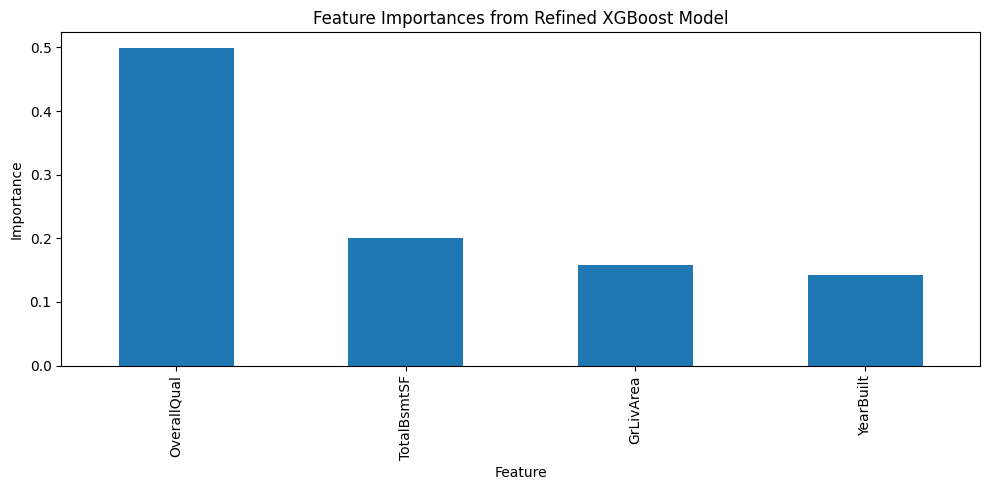

,Feature,Importance
1,OverallQual,0.498856
2,TotalBsmtSF,0.200266
0,GrLivArea,0.158280
3,YearBuilt,0.142598


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame to display feature importances with column names
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': X_train.columns[pipeline_lr['feature_selection'].get_support()],
        'Importance': pipeline_lr['model'].feature_importances_
    })
    .sort_values(by='Importance', ascending=False)
)

# Re-assign best_features order
best_features = df_feature_importance['Feature'].to_list()

# Print summary
print(f"These are the {len(best_features)} most important features in descending order.\n")
print(df_feature_importance['Feature'].to_list())

# Plot bar chart
df_feature_importance.plot(kind='bar', x='Feature', y='Importance', figsize=(10, 5), legend=False)
plt.title("Feature Importances from Refined XGBoost Model")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

df_feature_importance.head(10)




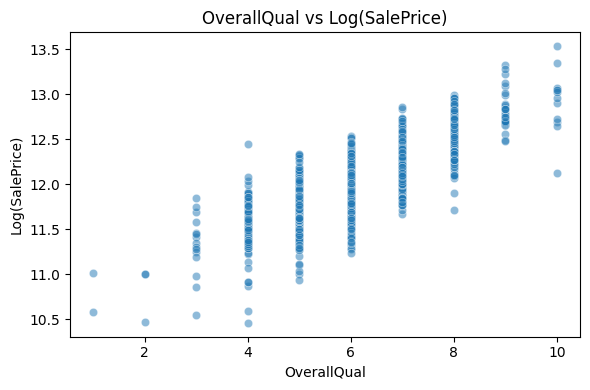

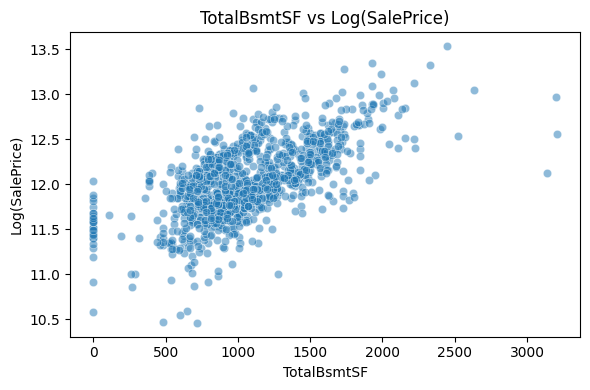

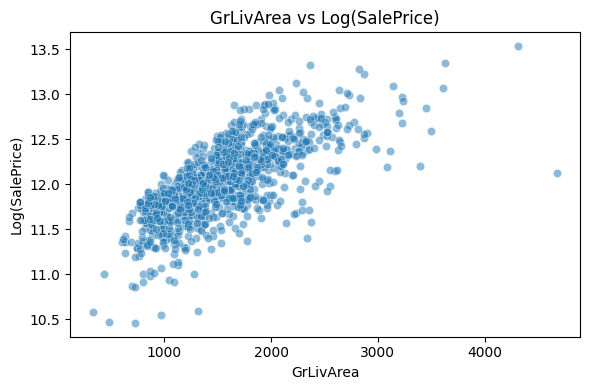

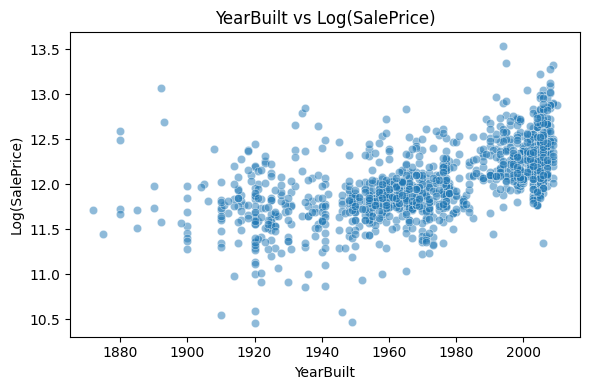

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Combine features and target into one DataFrame for plotting
train_df = X_train.copy()
train_df["SalePrice"] = y_train  

top_features = df_feature_importance['Feature'].head(10).to_list()

def plot_feature_vs_log_price(data, features):
    for feature in features:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=data, x=feature, y=np.log(data['SalePrice']), alpha=0.5)
        plt.title(f"{feature} vs Log(SalePrice)")
        plt.xlabel(feature)
        plt.ylabel("Log(SalePrice)")
        plt.tight_layout()
        plt.show()

plot_feature_vs_log_price(train_df, top_features)


#### Modeling with Best Features

After identifying the most important features, we now analyze the performance of a machine learning pipeline applied **only** to this reduced set. The goal is to determine whether a simpler model can achieve comparable predictive power (R² score) to the full-feature pipeline.

A simpler model can be advantageous for the business case, offering:
- Easier interpretability
- Faster inference time
- Lower maintenance complexity

To proceed, we:
1. Created copies of the training and test sets, keeping **only the selected best features**
2. Applied an updated ML pipeline tailored to this reduced feature set
3. Performed **hyperparameter optimization** on the candidate models
4. Evaluated model performance using our custom evaluation function

The results are then compared against the full-feature pipeline to assess the trade-off between simplicity and performance.


##### Train and Test Set for only best features

In [27]:
# Create new DataFrames with only the best features
best_features = df_feature_importance['Feature'].to_list()
X_train_top = X_train[best_features].copy()
X_test_top = X_test[best_features].copy()

Define a modified ML pipeline for best features

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def PipelineBestFeatures():
    pipeline = Pipeline([
        ("MedianImputer", SimpleImputer(strategy="median"))
    ])
    return pipeline


Models and Parameter of Hyperparameter Optimization

In [29]:
models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "Lasso": Lasso(random_state=42)
}

params = {
    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6, 10],
        "model__learning_rate": [0.01, 0.1]
    },
    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1, 1]
    }
}

##### Run Pipeline

In [30]:
pipeline_best_features = PipelineBestFeatures()
X_train_top = pipeline_best_features.fit_transform(X_train_top)
X_test_top = pipeline_best_features.transform(X_test_top)
print(X_train_top.shape, y_train.shape, X_test_top.shape, y_test.shape)

(1168, 4) (1168,) (292, 4) (292,)


##### Hyperparameter Optimization

In [31]:
search_top = HyperparameterOptimizationSearch(models, params)
search_top.fit(X_train_top, y_train_log, cv=5, verbose=2)

summary_df_top, gs_dict_top = search_top.score_summary()
summary_df_top.head()



 Running GridSearchCV for RandomForest 

Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Running GridSearchCV for XGBoost 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):



 Running GridSearchCV for Lasso 

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,min_score,mean_score,max_score,std_score,model__max_depth,model__n_estimators,model__learning_rate,model__alpha
18,Lasso,-0.09398,-0.074385,-0.06425,0.01099,NaN,NaN,NaN,0.001
19,Lasso,-0.092893,-0.075624,-0.065849,0.010316,NaN,NaN,NaN,0.01
3,RandomForest,-0.109725,-0.101606,-0.094198,0.006465,20,200,NaN,NaN
5,RandomForest,-0.109725,-0.101606,-0.094198,0.006465,None,200,NaN,NaN
1,RandomForest,-0.109725,-0.101606,-0.094198,0.006465,10,200,NaN,NaN


In [32]:
Evaluate_Function_Hyper(
    gs_dict=gs_dict_top,
    X_train=X_train_top,
    X_test=X_test_top,
    y_train=y_train,
    y_test=y_test,
    y_train_log=y_train_log,
    y_test_log=y_test_log
)


evaluate_original_scale
----------------------------------------
RANDOMFOREST
  Train RMSE: 44159.490333216796
  Test RMSE:  47705.82166259927
  Train MAE:  30956.276205542472
  Test MAE:   29836.47265643384
  Train R²:   0.6832754269897449
  Test R²:    0.6704467324997692
----------------------------------------
XGBOOST
  Train RMSE: 44154.14264746323
  Test RMSE:  47697.15084634772
  Train MAE:  30962.311202375855
  Test MAE:   29857.00610017123
  Train R²:   0.6833521326273548
  Test R²:    0.6705665181378571
----------------------------------------
LASSO
  Train RMSE: 39163.81619820422
  Test RMSE:  143782.6338162895
  Train MAE:  21462.53699590163
  Test MAE:   27190.776140167894
  Train R²:   0.7508828297653093
  Test R²:    -1.9936135153396917
----------------------------------------
evaluate_log_model
----------------------------------------
RANDOMFOREST
  Train RMSE: 0.10085679555660426
  Test RMSE:  0.09202453395249746
  Train MAE:  0.07622261079113105
  Test MAE:   0.0684977

##### Evaluation Results: Best Features vs Full Pipeline

After modeling using only the most important features (`OverallQual`, `TotalBsmtSF`, `YearRemodAdd`, and `GrLivArea`), we evaluated and compared the model performance against the full-feature pipeline.

Despite the appeal of a simpler model, the results clearly show that reducing the feature set led to a significant drop in performance, especially in terms of the R² score and error metrics on the test set.

**Key findings:**

- **RandomForest and XGBoost** achieved comparable performance with the reduced feature set, reaching test R² values around **0.67**, but still fell short of the **0.82–0.86** achieved by the full pipeline.
- **Lasso regression** failed to generalize well in both cases, showing negative R² scores on the test set in original scale, though log-scale performance was reasonable.
- The **full pipeline significantly outperforms** the reduced version, especially in MAE and RMSE metrics on the test set.

**Conclusion:**  
While the reduced-feature model is simpler and slightly faster, the trade-off in predictive power is too large. For our business case, where accurate price prediction is critical, the full pipeline remains the recommended solution.


----

# Push files to Repo

In this section we will proceed saving the corresponding files and models. Here we will save the following:

- Train Set
- Test Set
- Feature Engineering Pipeline
- Model Pipeline
  

In [33]:
import joblib
import os

version = 'v1'
file_path = f'outputs/ml_pipeline/saleprice/{version}'

try:
    os.makedirs(name=file_path)
except Exception as e:
    print(e)

[WinError 183] Cannot create a file when that file already exists: 'outputs/ml_pipeline/saleprice/v1'


Saving Train Set

In [34]:
X_train.to_csv(f"{file_path}/X_train.csv", index=False)
y_train.to_csv(f"{file_path}/y_train.csv", index=False)
y_train_log.to_csv(f"{file_path}/y_train_log.csv", index=False)

Saving Test Set

Saving feature engineering pipepline and extracting the necessary features

In [35]:
X_test.to_csv(f"{file_path}/X_test.csv", index=False)
y_test.to_csv(f"{file_path}/y_test.csv", index=False)
y_test_log.to_csv(f"{file_path}/y_test_log.csv", index=False)

In [36]:
pipeline_data_cleaning_feat_eng

raw_input_features = pipeline_data_cleaning_feat_eng.feature_names_in_
print(raw_input_features)

['1stFlrSF', '2ndFlrSF', 'BedroomAbvGr', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinType1', 'BsmtUnfSF', 'EnclosedPorch', 'GarageArea', 'GarageFinish', 'GarageYrBlt', 'GrLivArea', 'KitchenQual', 'LotArea', 'LotFrontage', 'MasVnrArea', 'OpenPorchSF', 'OverallCond', 'OverallQual', 'TotalBsmtSF', 'WoodDeckSF', 'YearBuilt', 'YearRemodAdd']


In [37]:
joblib.dump(value=pipeline_data_cleaning_feat_eng ,
            filename=f"{file_path}/lr_pipeline_data_cleaning_feat_eng.pkl")

['outputs/ml_pipeline/saleprice/v1/lr_pipeline_data_cleaning_feat_eng.pkl']

Save best parameter pipeline

In [38]:
joblib.dump(value=pipeline_rl_xgb,
            filename=f"{file_path}/lr_pipeline_model.pkl")

['outputs/ml_pipeline/saleprice/v1/lr_pipeline_model.pkl']